## 1. Data loading & shape

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            f1_score, accuracy_score, roc_auc_score)
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
print("Dataset loaded:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 2. Data cleaning & fixing 

In [2]:
print("TotalCharges dtype BEFORE fix:", df['TotalCharges'].dtype)
print("Rows with blank TotalCharges:", (df['TotalCharges'] == ' ').sum())

# Fix: replace spaces with NaN, then convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# These 11 rows have tenure=0 (brand new customers, never billed)
# Fill with 0 — they've been charged nothing yet
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("\nTotalCharges dtype AFTER fix:", df['TotalCharges'].dtype)
print("Missing values remaining:", df['TotalCharges'].isnull().sum())
print("\nSample of fixed values:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].head(5))

TotalCharges dtype BEFORE fix: str
Rows with blank TotalCharges: 11

TotalCharges dtype AFTER fix: float64
Missing values remaining: 0

Sample of fixed values:
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65


In [3]:
# Drop column customerID
df = df.drop(columns=['customerID'])

print("Shape after dropping customerID:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping customerID: (7043, 20)
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
# Convert the target column to numbers - Churn: Yes → 1, No → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Churn value counts after conversion:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Churn value counts after conversion:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


## 3. Encoding categorical features 

In [5]:
# Detect binary, three value and multi-categorical columns 
binary_cols = []
yes_no_cols = []
three_val_cols = []
multi_cat_cols = []

for col in df.select_dtypes(include='object').columns:
    raw_values = df[col].dropna().astype(str)
    values = set(raw_values.str.strip().str.lower())  # normalize
    
    # Check if it contains a "no service" variant
    has_no_service = any('no ' in v.lower() and 'service' in v.lower() 
                         for v in values)
    # Check if it's strictly yes/no
    is_yes_no = values.issubset({'yes', 'no'})
    
    if has_no_service:
        three_val_cols.append(col)
    elif len(values) == 2:
        binary_cols.append(col)
        if values.issubset({'yes', 'no'}):
            yes_no_cols.append(col)
    else:
        multi_cat_cols.append(col)

print("Yes/No columns:", yes_no_cols)
print("Binary columns:", binary_cols)
print("Three-value columns (contain 'no service'):", three_val_cols)
print("Multi-category columns:", multi_cat_cols)

Yes/No columns: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Three-value columns (contain 'no service'): ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
Multi-category columns: ['InternetService', 'Contract', 'PaymentMethod']


In [6]:
# These columns only have two values: Yes → 1, No → 0
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

# gender: Female → 0, Male → 1
df['gender'] = (df['gender'] == 'Male').astype(int)

# Yes/No columns
for col in yes_no_cols:
    df[col] = (df[col] == 'Yes').astype(int)

print("\nAfter encoding:")
print(df[['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']].head())

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

After encoding:
   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        1           0             0                 1
1       1        0           0             1                 0
2       1        0           0             1                 1
3       1        0           0             0                 0
4       0        0           0             1                 1


In [7]:
# Handle 3-value columns (No/Yes/No service)
for col in three_val_cols:
    print(f"{col}: {df[col].unique()}")

MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


In [8]:
# Treat "No phone service" and "No internet service" as "No"
for col in three_val_cols:
    df[col] = df[col].replace({'No phone service': 'No', 
                                'No internet service': 'No'})
    df[col] = (df[col] == 'Yes').astype(int)

print("\nAfter encoding:")
print(df[three_val_cols].head())


After encoding:
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   
3              0               1             0                 1            1   
4              0               0             0                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  
3            0                0  
4            0                0  


In [9]:
# Encode multi-category columns with one-hot encoding
for col in multi_cat_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())


Column: InternetService
Unique values: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Column: Contract
Unique values: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Column: PaymentMethod
Unique values: <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


In [10]:
# One-hot encode the multi-category columns
df = pd.get_dummies(df, 
                    columns=multi_cat_cols,
                    drop_first=True)

print("Shape after one-hot encoding:", df.shape)
print("New columns created:")
print([col for col in df.columns if any(x in col for x in 
      ['InternetService', 'Contract', 'PaymentMethod'])])

Shape after one-hot encoding: (7043, 24)
New columns created:
['InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [11]:
print("Final dataset shape:", df.shape)
print("\nAll columns:")
for col in df.columns:
    print(f"  {col}: dtype={df[col].dtype}, unique values={df[col].nunique()}")
df.head()

Final dataset shape: (7043, 24)

All columns:
  gender: dtype=int64, unique values=2
  SeniorCitizen: dtype=int64, unique values=2
  Partner: dtype=int64, unique values=2
  Dependents: dtype=int64, unique values=2
  tenure: dtype=int64, unique values=73
  PhoneService: dtype=int64, unique values=2
  MultipleLines: dtype=int64, unique values=2
  OnlineSecurity: dtype=int64, unique values=2
  OnlineBackup: dtype=int64, unique values=2
  DeviceProtection: dtype=int64, unique values=2
  TechSupport: dtype=int64, unique values=2
  StreamingTV: dtype=int64, unique values=2
  StreamingMovies: dtype=int64, unique values=2
  PaperlessBilling: dtype=int64, unique values=2
  MonthlyCharges: dtype=float64, unique values=1585
  TotalCharges: dtype=float64, unique values=6531
  Churn: dtype=int64, unique values=2
  InternetService_Fiber optic: dtype=bool, unique values=2
  InternetService_No: dtype=bool, unique values=2
  Contract_One year: dtype=bool, unique values=2
  Contract_Two year: dtype=bool

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


## 4. Train / test split & scaling 

In [12]:
# Split into features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (7043, 23)
Target shape: (7043,)

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [13]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # for reproducibility
    stratify=y           # keeps churn ratio balanced in both sets
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set: {y_test.mean()*100:.1f}%")

Training set size: (5634, 23)
Test set size: (1409, 23)

Churn rate in training set: 26.5%
Churn rate in test set: 26.5%


In [14]:
# Scale numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling complete.")
print("\nBefore scaling, tenure ranged 0–72 months")
print("After scaling, tenure should be centered around 0:")
print(X_train['tenure'].describe().round(3))

Scaling complete.

Before scaling, tenure ranged 0–72 months
After scaling, tenure should be centered around 0:
count    5634.000
mean       -0.000
std         1.000
min        -1.322
25%        -0.956
50%        -0.142
75%         0.916
max         1.608
Name: tenure, dtype: float64


In [15]:
# Save the scaler and column names
joblib.dump(scaler, 'scaler.pkl')

# Save the column names in the exact order the model expects
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Saved: scaler.pkl")
print("Saved: feature_columns.pkl")
print("\nFeature columns (in order):")
print(feature_columns)

Saved: scaler.pkl
Saved: feature_columns.pkl

Feature columns (in order):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 5. Model training 

In [16]:
# Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees vote together
    random_state=42,     # reproducibility
    n_jobs=-1,            # use all CPU cores
    class_weight='balanced' 
)

model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features: {model.n_features_in_}")

Model trained successfully!
Number of trees: 100
Number of features: 23


## 6. Model evaluation 

In [17]:
# Evaluate the model - Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of churn

# Print all metrics
print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba)*100:.1f}%")

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

MODEL EVALUATION RESULTS

Accuracy:  79.6%
F1 Score:  56.9%
ROC-AUC:   82.7%

Detailed classification report:
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.87      1035
     Churned       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



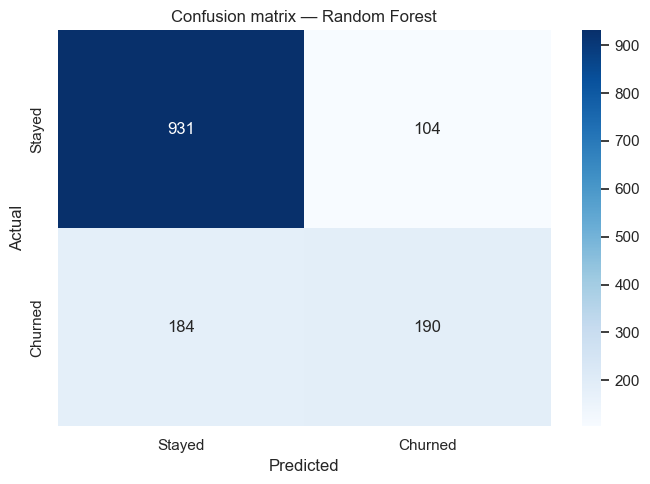


True Negatives  (correctly predicted 'stayed'):  931
False Positives (predicted 'churned', actually stayed): 104
False Negatives (predicted 'stayed', actually churned): 184
True Positives  (correctly predicted 'churned'): 190


In [18]:
# Plot the confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Explain what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted 'stayed'):  {tn}")
print(f"False Positives (predicted 'churned', actually stayed): {fp}")
print(f"False Negatives (predicted 'stayed', actually churned): {fn}")
print(f"True Positives  (correctly predicted 'churned'): {tp}")

## 7. Feature importance 

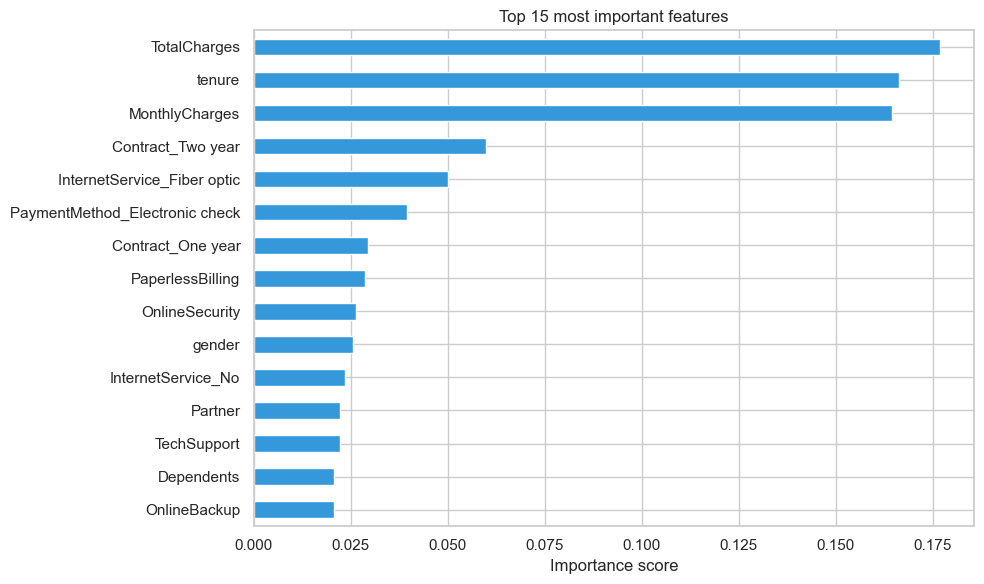


Top 10 most important features:
TotalCharges                      0.1767
tenure                            0.1662
MonthlyCharges                    0.1645
Contract_Two year                 0.0598
InternetService_Fiber optic       0.0501
PaymentMethod_Electronic check    0.0396
Contract_One year                 0.0296
PaperlessBilling                  0.0287
OnlineSecurity                    0.0263
gender                            0.0256
dtype: float64


In [19]:
# Feature importance from the trained model
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='#3498db')
plt.title('Top 15 most important features')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importances.head(10).round(4))

In [20]:
# Save the model
joblib.dump(model, 'churn_model.pkl')
print("Model saved to: churn_model.pkl")

# Verify we can load it back
loaded_model = joblib.load('churn_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print("Verified model loads correctly. Sample predictions:", test_pred)

Model saved to: churn_model.pkl
Verified model loads correctly. Sample predictions: [0 1 0 0 0]


## Phase 2 Summary — Preprocessing and Model Training

### Data cleaning steps performed
1. Fixed TotalCharges column (text → float, 11 blanks filled with 0)
2. Dropped customerID (no predictive value)
3. Encoded binary columns: gender, Partner, Dependents, PhoneService, PaperlessBilling
4. Encoded 3-value columns: MultipleLines, OnlineSecurity, OnlineBackup,
   DeviceProtection, TechSupport, StreamingTV, StreamingMovies
5. One-hot encoded: InternetService, Contract, PaymentMethod
6. Scaled numerical features: tenure, MonthlyCharges, TotalCharges

### Model performance
- Accuracy: 79.6%
- F1 Score: 56.9%
- ROC-AUC: 82.7%

### Key observations
- Feature importances confirm Phase 1 EDA findings: tenure, monthly charges,
  and contract type are the strongest predictors
- The model correctly identifies the majority of churners
- False negatives (missed churners) represent the main business risk
- Low F1 (57%) expected due to class imbalance — addressed with class_weight='balanced'

### Files saved
- churn_model.pkl — trained Random Forest model
- scaler.pkl — fitted StandardScaler for new data
- feature_columns.pkl — column names in correct order